In [ ]:
!pip install ultralytics
from IPython.display import display, clear_output
clear_output()

In [ ]:
import os
import pandas as pd
from PIL import Image
import cv2
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
model = YOLO("yolo11s.pt")



In [ ]:
yaml_file_path = '/content/drive/MyDrive/model_train/BrainTumorYolov8/data.yaml'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
results = model.train( data= yaml_file_path,epochs=50,patience=20, batch= -1, optimizer='auto')

Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/model_train/BrainTumorYolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, per

In [ ]:
post_training_files_path = '/content/runs/detect/train'

In [ ]:
best_model_path = os.path.join(post_training_files_path, 'weights/best.pt')

In [ ]:
best_model = YOLO('/content/runs/detect/train/weights/best.pt')

In [ ]:
metrics = best_model.val(split='val')

Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 16.4±6.3 MB/s, size: 32.4 KB)
val: Scanning /content/drive/MyDrive/model_train/BrainTumorYolov8/valid/labels.cache... 612 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 612/612 839.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 3.6it/s 10.7s
                   all        612        612      0.915       0.87      0.928      0.716
               class_0        285        285       0.85      0.712      0.831      0.558
               class_1        142        142      0.964      0.951      0.981      0.832
               class_2        185        185      0.931      0.947      0.972      0.759
Speed: 2.6ms preprocess, 4.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /co

In [ ]:
metrics_df = pd.DataFrame(metrics.summary())
metrics_df

,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
0,class_0,285,285,0.85048,0.71228,0.77527,0.83115,0.55814
1,class_1,142,142,0.96366,0.95070,0.95714,0.98103,0.83159
2,class_2,185,185,0.93090,0.94662,0.93869,0.97175,0.75931


In [ ]:
# Extract overall metrics from the 'metrics' object
overall_precision = metrics.box.mp
overall_recall = metrics.box.mr
overall_map50 = metrics.box.map50
overall_map50_95 = metrics.box.map

# Extract fitness score from the 'results' object (from training)
fitness_score = results.fitness

# Create a dictionary for the DataFrame
data_to_display = {
    'Metric': [
        'metrics/precision(B)',
        'metrics/recall(B)',
        'metrics/mAP50(B)',
        'metrics/mAP50-95(B)',
        'fitness'
    ],
    'Value': [
        overall_precision,
        overall_recall,
        overall_map50,
        overall_map50_95,
        fitness_score
    ]
}

# Create the DataFrame
overall_metrics_df = pd.DataFrame(data_to_display)
display(overall_metrics_df)

,Metric,Value
0,metrics/precision(B),0.915013
1,metrics/recall(B),0.869869
2,metrics/mAP50(B),0.927975
3,metrics/mAP50-95(B),0.716344
4,fitness,0.716701


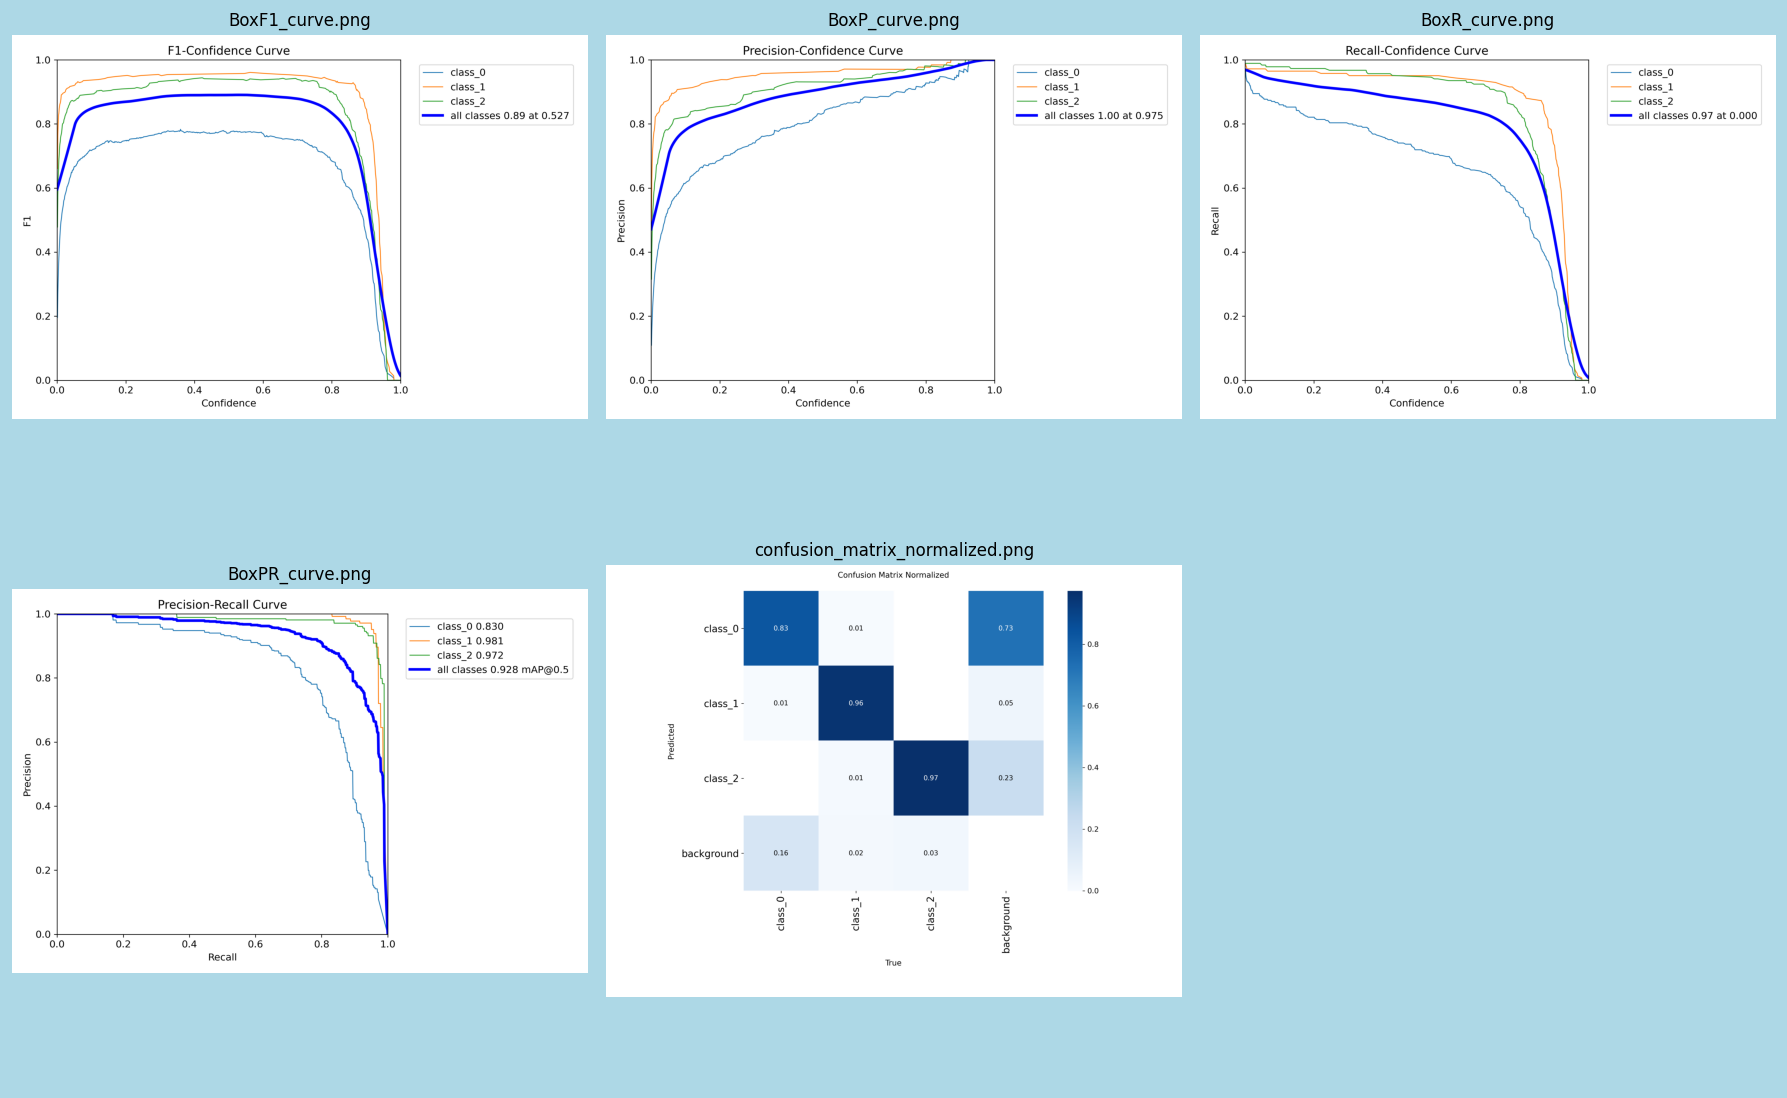

In [ ]:
def display_images_in_frame_with_background(post_training_files_path, image_files, background_color='lightgray'):
    # Calculate grid size (rows and columns)
    num_images = len(image_files)
    cols = 3  # Number of columns (you can adjust this as needed)
    rows = (num_images + cols - 1) // cols  # Calculate the number of rows needed

    # Set up the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), dpi=120)
    fig.patch.set_facecolor(background_color)  # Set the figure background color
    axes = axes.flatten()  # Flatten to easily index

    for i, image_file in enumerate(image_files):
        image_path = os.path.join(post_training_files_path, image_file)
        img = cv2.imread(image_path)
        # Check if the image was loaded successfully
        if img is None:
            print(f"Warning: Could not load image from {image_path}. Skipping.")
            axes[i].text(0.5, 0.5, f"Image not found: {image_file}", horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes, color='red')
            axes[i].axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].axis('off')  # Turn off axis
        axes[i].set_title(image_file, fontsize=10, color='black')  # Add title with black text

    # Turn off unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# List of image files to display
image_files = [
    'BoxF1_curve.png', # Corrected filename
    'BoxP_curve.png',  # Corrected filename
    'BoxR_curve.png',  # Corrected filename
    'BoxPR_curve.png', # Corrected filename
    'confusion_matrix_normalized.png',
]

# Path to the directory containing the images
post_training_files_path = '/content/runs/detect/train' # Corrected path

# Display the images with a background color
display_images_in_frame_with_background(post_training_files_path, image_files, background_color='lightblue')

In [ ]:
import os

directory_path = '/content/runs/detect/train'

if os.path.exists(directory_path):
    print(f"Listing contents of: {directory_path}")
    for item in os.listdir(directory_path):
        print(item)
else:
    print(f"Directory not found: {directory_path}")

Listing contents of: /content/runs/detect/train
BoxF1_curve.png
val_batch1_pred.jpg
val_batch2_pred.jpg
val_batch2_labels.jpg
BoxP_curve.png
results.png
train_batch1.jpg
train_batch1481.jpg
confusion_matrix.png
val_batch0_pred.jpg
train_batch1482.jpg
labels.jpg
train_batch1480.jpg
val_batch1_labels.jpg
val_batch0_labels.jpg
train_batch0.jpg
train_batch2.jpg
results.csv
confusion_matrix_normalized.png
weights
BoxPR_curve.png
BoxR_curve.png
args.yaml



0: 640x640 1 class_2, 18.9ms
Speed: 2.8ms preprocess, 18.9ms inference, 7.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 class_2, 8.4ms
Speed: 1.9ms preprocess, 8.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 class_1, 10.5ms
Speed: 2.4ms preprocess, 10.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 class_1, 83.2ms
Speed: 7.6ms preprocess, 83.2ms inference, 11.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 class_0, 40.3ms
Speed: 4.2ms preprocess, 40.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 class_0, 9.5ms
Speed: 1.8ms preprocess, 9.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 10.9ms
Speed: 2.2ms preprocess, 10.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 class_0, 8.9ms
Speed: 3.4ms preprocess, 8.9ms inference, 2.3ms postprocess per image at shape 

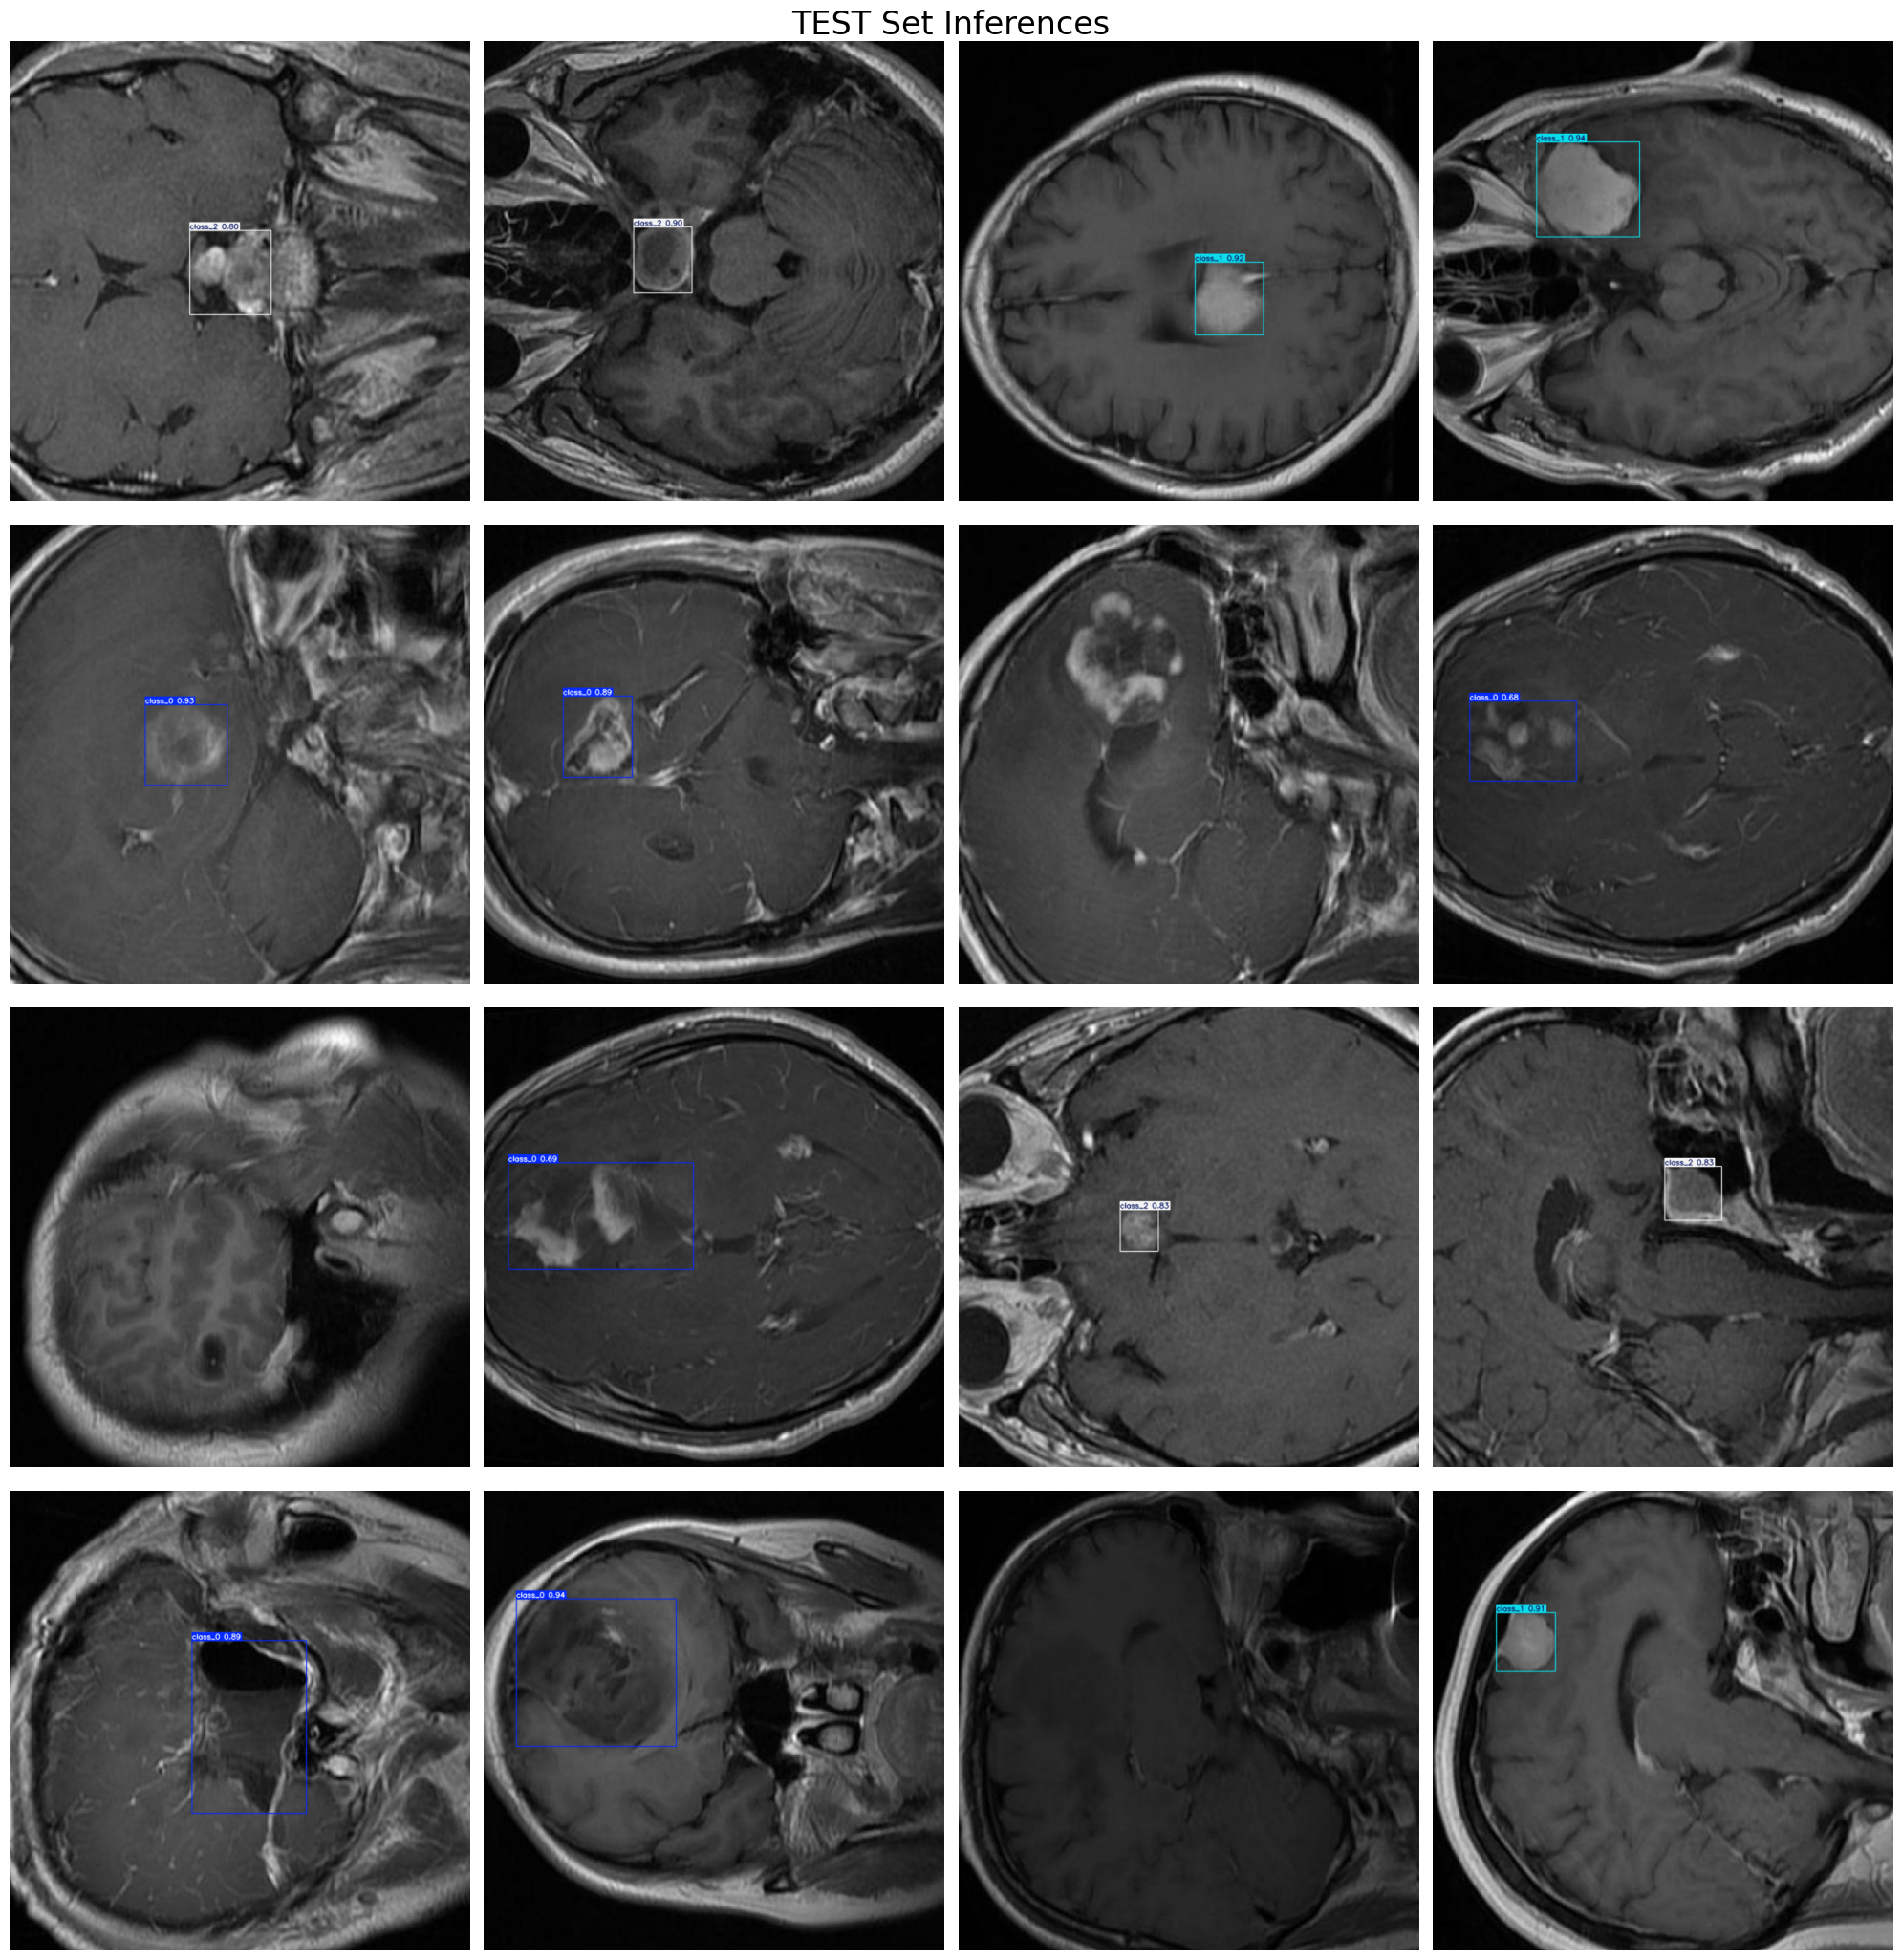

In [ ]:
 #Validation of Model by TestSet

# Normalization function
def normalize_image(image):
    return image / 255.0

# Image resizing function
def resize_image(image, size=(640, 640)):
    return cv2.resize(image, size)

# Path to validation images
dataset_path = '/content/drive/MyDrive/model_train/BrainTumorYolov8'  # Place your dataset path here
valid_images_path = os.path.join(dataset_path, 'test', 'images')
# List of all jpg images in the directory
image_files = [file for file in os.listdir(valid_images_path) if file.endswith('.jpg')]

# Check if there are images in the directory
if len(image_files) > 0:
    # Select 9 images at equal intervals
    num_images = len(image_files)
    step_size = max(1, num_images // 16)  # Ensure the interval is at least 1
    selected_images = [image_files[i] for i in range(0, num_images, step_size)]

    # Prepare subplots
    fig, axes = plt.subplots(4, 4, figsize=(20, 21))
    fig.suptitle('TEST Set Inferences', fontsize=24)

    for i, ax in enumerate(axes.flatten()):
        if i < len(selected_images):
            image_path = os.path.join(valid_images_path, selected_images[i])

            # Load image
            image = cv2.imread(image_path)

            # Check if the image is loaded correctly
            if image is not None:
               # Resize image
                resized_image = resize_image(image, size=(640, 640))
                # Normalize image
                normalized_image = normalize_image(resized_image)

                # Convert the normalized image to uint8 data type
                normalized_image_uint8 = (normalized_image * 255).astype(np.uint8)

                # Predict with the model
                results = best_model.predict(source=normalized_image_uint8, imgsz=640, conf=0.5)

                # Plot image with labels
                annotated_image = results[0].plot(line_width=1)
                annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
                ax.imshow(annotated_image_rgb)
            else:
                print(f"Failed to load image {image_path}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
ca